# Atlas Travel Agent — Step-Through Debugger

Walk through the multi-phase LangGraph **one node at a time** using `MemorySaver` breakpoints.

The graph has 5 phases:
1. **ingest** — parse user query → structured JSON
2. **enrich** — merge with user profile / preferences
3. **decompose** — break into an ordered task plan
4. **execute** — ReAct loop: call tools, gather research
5. **synthesise** — assemble final itinerary

We compile with `interrupt_before` on nodes 2–5 so we can pause, inspect state, and resume at each step.

## 1. Install & Import Dependencies

In [11]:
import json
from pprint import pprint

from IPython.display import Image, Markdown, display

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph
from langgraph.prebuilt import ToolNode

# Atlas imports — uses the existing module without modifications
from atlas.llm import get_llm
from atlas.tools import ALL_TOOLS
from atlas.agents.travel_agent import (
    AgentState,
    _make_ingest_node,
    _make_enrich_node,
    _make_decompose_node,
    _make_execute_node,
    _make_synthesise_node,
    _should_continue,
)

print("✅ All imports successful")

✅ All imports successful


## 2. Configure the LLM & Inspect Available Tools

In [12]:
llm = get_llm()

# Extract just the model name from the LLM instance
model_name = getattr(llm, "model", None) or getattr(llm, "model_name", "unknown")
print(f"🤖 Model: {model_name}")
print(f"🌡️  Temperature: {getattr(llm, 'temperature', 'default')}\n")

print("Available tools for the execute phase:")
print("=" * 60)
for i, tool in enumerate(ALL_TOOLS, 1):
    # Get the first line of the description (before any newlines)
    short_desc = tool.description.split("\n")[0].strip()
    print(f"  {i}. 🔧 {tool.name}")
    print(f"     {short_desc}")
    print()

🤖 Model: gemini/gemini-2.5-flash
🌡️  Temperature: 0.7

Available tools for the execute phase:
  1. 🔧 search_web
     Search the web for travel-related information.

  2. 🔧 search_places
     Search for places, attractions, and points of interest.

  3. 🔧 get_weather
     Get daily temperature summaries for *city* from *start_date* to *end_date*.

  4. 🔧 save_itinerary
     Save a trip itinerary to disk as a JSON file.

  5. 🔧 export_itinerary_markdown
     Export a trip itinerary as a Markdown file to the user's Downloads folder.



## 3. Build the Graph with Breakpoints

We rebuild the same graph as `build_travel_agent()` but compile it with:
- **`checkpointer=MemorySaver()`** — enables state persistence between invocations
- **`interrupt_before=["enrich", "decompose", "execute", "synthesise"]`** — pause *before* every phase after ingest

This means the first `invoke()` will run **ingest** and then stop.

In [3]:
checkpointer = MemorySaver()

# Re-create the exact same graph topology from travel_agent.py
builder = StateGraph(AgentState)

builder.add_node("ingest", _make_ingest_node(llm))
builder.add_node("enrich", _make_enrich_node(llm))
builder.add_node("decompose", _make_decompose_node(llm))
builder.add_node("execute", _make_execute_node(llm))
builder.add_node("tools", ToolNode(tools=ALL_TOOLS))
builder.add_node("synthesise", _make_synthesise_node(llm))

builder.set_entry_point("ingest")
builder.add_edge("ingest", "enrich")
builder.add_edge("enrich", "decompose")
builder.add_edge("decompose", "execute")
builder.add_conditional_edges(
    "execute",
    _should_continue,
    {"tools": "tools", "synthesise": "synthesise"},
)
builder.add_edge("tools", "execute")
builder.add_edge("synthesise", END)

# Compile WITH breakpoints
graph = builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["enrich", "decompose", "execute", "synthesise"],
)

print("✅ Graph compiled with breakpoints before: enrich, decompose, execute, synthesise")

✅ Graph compiled with breakpoints before: enrich, decompose, execute, synthesise


## 4. Visualize the Graph Topology

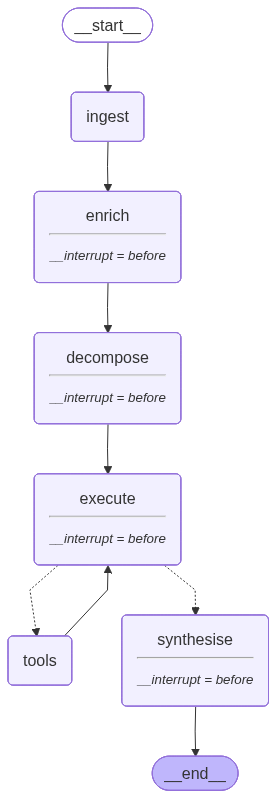

In [4]:
# Try PNG first (requires pip install grandalf), fall back to Mermaid text
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

## 5. Prepare Initial State & Run Until First Breakpoint

The first `invoke()` runs **ingest** (parses the user query into structured JSON) and then pauses before **enrich**.

In [5]:
# Thread ID ties all resume calls to the same checkpoint chain
config = {"configurable": {"thread_id": "debug-walkthrough-1"}}

initial_state = {
    "messages": [
        HumanMessage(
            content=(
                "Plan a 5-day trip to Kyoto, Japan for a couple who loves "
                "temples and street food, budget around $3000"
            )
        )
    ],
    "parsed_query": None,
    "user_profile": None,
    "task_plan": None,
}

# This runs INGEST then pauses before ENRICH
result = graph.invoke(initial_state, config)
print("⏸️  Paused! Graph is waiting before the next node.")

⏸️  Paused! Graph is waiting before the next node.


## 6. Inspect State After Ingest Phase

`get_state()` returns the checkpoint snapshot. We can see:
- **`parsed_query`** — the structured JSON the ingest LLM produced
- **`snapshot.next`** — which node runs next (should be `enrich`)

In [6]:
snapshot = graph.get_state(config)

print(f"▶ Next node(s): {snapshot.next}\n")
print("── Parsed Query (from ingest) ──")
print(json.dumps(snapshot.values.get("parsed_query"), indent=2))

print(f"\n── Messages so far: {len(snapshot.values['messages'])} ──")
for i, msg in enumerate(snapshot.values["messages"]):
    print(f"  [{i}] {type(msg).__name__}: {str(msg.content)[:120]}...")

▶ Next node(s): ('enrich',)

── Parsed Query (from ingest) ──
{
  "intent": "plan_trip",
  "destination": "Kyoto",
  "country": "Japan",
  "start_date": null,
  "end_date": null,
  "duration_days": 5,
  "interests": [
    "temples",
    "street food"
  ],
  "budget_usd": 3000,
  "traveler_count": 2,
  "pace": null,
  "constraints": [],
  "raw_query": "Plan a 5-day trip to Kyoto, Japan for a couple who loves temples and street food, budget around $3000"
}

── Messages so far: 2 ──
  [0] HumanMessage: Plan a 5-day trip to Kyoto, Japan for a couple who loves temples and street food, budget around $3000...
  [1] AIMessage: ```json
{
  "intent": "plan_trip",
  "destination": "Kyoto",
  "country": "Japan",
  "start_date": null,
  "end_date": n...


## 7. Resume → Enrich Phase

Calling `graph.invoke(None, config)` resumes from the checkpoint. It runs **enrich** (merges parsed query with user profile) then pauses before **decompose**.

In [8]:
# Resume: runs ENRICH, pauses before DECOMPOSE
graph.invoke(None, config)

snapshot = graph.get_state(config)
print(f"▶ Next node(s): {snapshot.next}\n")

print("── Enriched Query (parsed_query after enrich) ──")
print(json.dumps(snapshot.values.get("parsed_query"), indent=2))

print("\n── User Profile ──")
print(json.dumps(snapshot.values.get("user_profile"), indent=2))

▶ Next node(s): ('execute',)

── Enriched Query (parsed_query after enrich) ──
{
  "destination": "Kyoto",
  "country": "Japan",
  "start_date": null,
  "end_date": null,
  "duration_days": 5,
  "interests": [
    "temples",
    "street food",
    "culture",
    "sightseeing"
  ],
  "budget_usd": 3000,
  "traveler_count": 2,
  "pace": "moderate",
  "constraints": [],
  "profile_hints": [
    "User historically prefers culture and sightseeing activities",
    "User historically prefers a moderate pace"
  ]
}

── User Profile ──
{
  "favourite_destination_types": [
    "coastal cities",
    "historic towns",
    "mountain retreats"
  ],
  "favourite_categories": [
    "food",
    "culture",
    "sightseeing"
  ],
  "preferred_pace": "moderate",
  "typical_budget_usd": 3000.0,
  "past_destinations": [
    "Tokyo",
    "Barcelona",
    "Reykjavik",
    "Lisbon",
    "Chiang Mai"
  ],
  "trip_count": 5,
  "updated_at": "2026-02-15T10:30:00Z"
}


## 8. Resume → Decompose Phase

Runs **decompose** which produces an ordered task plan, then pauses before **execute**.

In [9]:
# Resume: runs DECOMPOSE, pauses before EXECUTE
graph.invoke(None, config)

snapshot = graph.get_state(config)
print(f"▶ Next node(s): {snapshot.next}\n")

print("── Task Plan ──")
task_plan = snapshot.values.get("task_plan", [])
print(json.dumps(task_plan, indent=2))

▶ Next node(s): ('execute',)

── Task Plan ──
[
  {
    "step": 1,
    "task": "Suggest suitable travel dates",
    "description": "Propose optimal 5-day travel dates for Kyoto, considering seasonal weather and peak tourist times, as the original query did not specify dates.",
    "tools_needed": []
  },
  {
    "step": 2,
    "task": "Research Kyoto attractions and culture",
    "description": "Gather information on key temples, cultural sites, popular street food areas, and general sightseeing opportunities in Kyoto relevant to a 5-day trip for two travelers interested in culture and food.",
    "tools_needed": [
      "search_web",
      "search_places"
    ]
  },
  {
    "step": 3,
    "task": "Check weather for suggested dates",
    "description": "Retrieve weather forecasts and typical climate conditions for Kyoto during the suggested travel dates to inform packing and activity planning.",
    "tools_needed": [
      "get_weather"
    ]
  },
  {
    "step": 4,
    "task": "Plan f

## 9. Resume → Execute ↔ Tools Loop

The **execute** phase is where the agent calls tools (search, weather, etc.) in a ReAct loop.

Each `invoke(None, config)` runs one step — either the execute node or the tools node. We loop until `_should_continue` routes to `synthesise`.

> **Note:** If your tools use live APIs, you'll see real tool calls here. If they're mocked/placeholder, you'll see the placeholder responses.

In [13]:
# Step through the execute ↔ tools loop one iteration at a time.
# Each call to invoke(None, config) advances one node.
iteration = 0
MAX_ITERATIONS = 20  # safety limit

while iteration < MAX_ITERATIONS:
    iteration += 1
    graph.invoke(None, config)
    snapshot = graph.get_state(config)
    next_nodes = snapshot.next

    last_msg = snapshot.values["messages"][-1]
    print(f"── Iteration {iteration} ──")
    print(f"  Next: {next_nodes}")
    print(f"  Last message type: {type(last_msg).__name__}")

    # Show tool calls if present
    if isinstance(last_msg, AIMessage) and last_msg.tool_calls:
        for tc in last_msg.tool_calls:
            print(f"  🔧 Tool call: {tc['name']}({json.dumps(tc['args'], indent=4)[:200]})")

    # Show tool responses
    if hasattr(last_msg, "name") and last_msg.name:
        print(f"  📋 Tool response ({last_msg.name}): {str(last_msg.content)[:200]}...")

    # If next is synthesise or empty, we're done with execute
    if "synthesise" in next_nodes or not next_nodes:
        print(f"\n✅ Execute phase complete after {iteration} iteration(s)")
        break

    print()

── Iteration 1 ──
  Next: ('execute',)
  Last message type: ToolMessage
  📋 Tool response (search_places): {"query": "Nishiki Market Kyoto", "places": [{"title": "Nishiki Market", "address": "Kyoto, Japan", "latitude": 35.005024, "longitude": 135.76472, "rating": 4.3, "review_count": 50000, "category": "Ma...

── Iteration 2 ──
  Next: ('execute',)
  Last message type: ToolMessage
  📋 Tool response (search_places): {"query": "Gion district Kyoto", "places": []}...

── Iteration 3 ──
  Next: ('execute',)
  Last message type: ToolMessage
  📋 Tool response (search_places): {"query": "Gion district Kyoto", "places": []}...

── Iteration 4 ──
  Next: ('execute',)
  Last message type: ToolMessage
  📋 Tool response (search_web): {"query": "best temples cultural sites street food Kyoto 5-day trip", "results": [{"title": "Perfect 5 Day Itinerary for Kyoto, Japan - DESKRIB", "link": "https://deskrib.com/2025/12/08/perfect-5-day-...

── Iteration 5 ──
  Next: ('execute',)
  Last message type: Too

RateLimitError: litellm.RateLimitError: litellm.RateLimitError: geminiException - {
  "error": {
    "code": 429,
    "message": "You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 22.300158287s.",
    "status": "RESOURCE_EXHAUSTED",
    "details": [
      {
        "@type": "type.googleapis.com/google.rpc.Help",
        "links": [
          {
            "description": "Learn more about Gemini API quotas",
            "url": "https://ai.google.dev/gemini-api/docs/rate-limits"
          }
        ]
      },
      {
        "@type": "type.googleapis.com/google.rpc.QuotaFailure",
        "violations": [
          {
            "quotaMetric": "generati

## 10. Resume → Synthesise & Finish

The final `invoke` runs **synthesise** (assembles the complete itinerary) and reaches `END`.

In [ ]:
# Resume: runs SYNTHESISE → END
graph.invoke(None, config)

snapshot = graph.get_state(config)
print(f"▶ Next node(s): {snapshot.next}")
print(f"   (empty = graph complete ✅)")
print(f"\n── Total messages in conversation: {len(snapshot.values['messages'])} ──")

## 11. Display the Final Itinerary

The last `AIMessage` contains the synthesised travel itinerary in markdown format.

In [ ]:
final_state = graph.get_state(config)
final_msg = final_state.values["messages"][-1]

# Count tool calls across the full run
tool_call_count = sum(
    len(m.tool_calls)
    for m in final_state.values["messages"]
    if isinstance(m, AIMessage) and m.tool_calls
)
print(f"📊 Stats: {len(final_state.values['messages'])} messages, {tool_call_count} tool calls\n")
print("=" * 60)

# Render as formatted markdown
display(Markdown(final_msg.content))

## 12. Experiment: Modify State Mid-Run

This shows the real power of breakpoints — you can **edit the agent's state** between phases and resume.

Here we start a fresh run, pause after ingest, then swap the destination from Kyoto to Osaka to see how the downstream phases adapt.

In [ ]:
# Fresh thread for the experiment
exp_config = {"configurable": {"thread_id": "experiment-swap-destination"}}

# Run ingest, pause before enrich
graph.invoke(initial_state, exp_config)
snapshot = graph.get_state(exp_config)

print("── BEFORE update_state ──")
print(f"  Destination: {snapshot.values['parsed_query'].get('destination')}")
print(f"  Next node: {snapshot.next}")

# Modify the parsed_query: swap Kyoto → Osaka, bump budget
modified_query = dict(snapshot.values["parsed_query"])
modified_query["destination"] = "Osaka"
modified_query["budget_usd"] = 4000

# Inject the modified state
graph.update_state(exp_config, {"parsed_query": modified_query})

snapshot = graph.get_state(exp_config)
print("\n── AFTER update_state ──")
print(f"  Destination: {snapshot.values['parsed_query'].get('destination')}")
print(f"  Budget: ${snapshot.values['parsed_query'].get('budget_usd')}")
print(f"  Next node: {snapshot.next}")
print("\n💡 Now resume with graph.invoke(None, exp_config) to see enrich/decompose use Osaka!")

In [ ]:
# Resume the modified run through enrich → decompose (pauses before execute)
graph.invoke(None, exp_config)  # enrich
graph.invoke(None, exp_config)  # decompose

snapshot = graph.get_state(exp_config)
print(f"▶ Next: {snapshot.next}")
print(f"\n── Task Plan (now for Osaka!) ──")
print(json.dumps(snapshot.values.get("task_plan"), indent=2))